# Visualizaciones para Informe - Sistema de Ruteo Resiliente

Este notebook genera visualizaciones para el paper IEEE sobre el sistema de ruteo resiliente ante inundaciones urbanas en Santiago.

In [3]:
# Instalacion de dependencias (ejecutar si es necesario)
# !pip install pandas matplotlib seaborn folium geopandas psycopg2-binary plotly

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# Configuracion de estilo
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

## 1. Datos de la Red Vial

In [5]:
# Datos de la red vial por tipo de via
highway_data = pd.DataFrame({
    'tipo_via': ['living_street', 'footway', 'service', 'residential', 'tertiary', 
                 'primary', 'secondary', 'motorway', 'steps', 'busway', 
                 'unclassified', 'path', 'primary_link', 'pedestrian', 'track'],
    'cantidad': [36048, 29881, 22626, 18910, 6428, 5291, 5002, 1235, 994, 910, 
                 887, 859, 814, 694, 688],
    'km': [3816.6, 3266.8, 2002.0, 4226.5, 1529.4, 865.7, 958.6, 360.7, 16.4, 
           171.6, 257.8, 329.3, 47.7, 125.9, 319.8]
})

# Clasificacion de tipos de via
vehicular = ['living_street', 'residential', 'tertiary', 'primary', 'secondary', 
             'motorway', 'busway', 'unclassified', 'primary_link', 'track', 'service']
peatonal = ['footway', 'steps', 'pedestrian', 'path']

highway_data['categoria'] = highway_data['tipo_via'].apply(
    lambda x: 'Vehicular' if x in vehicular else 'Peatonal'
)

print(f"Total de aristas: {highway_data['cantidad'].sum():,}")
print(f"Total de kilometros: {highway_data['km'].sum():,.1f} km")

Total de aristas: 131,267
Total de kilometros: 18,294.8 km


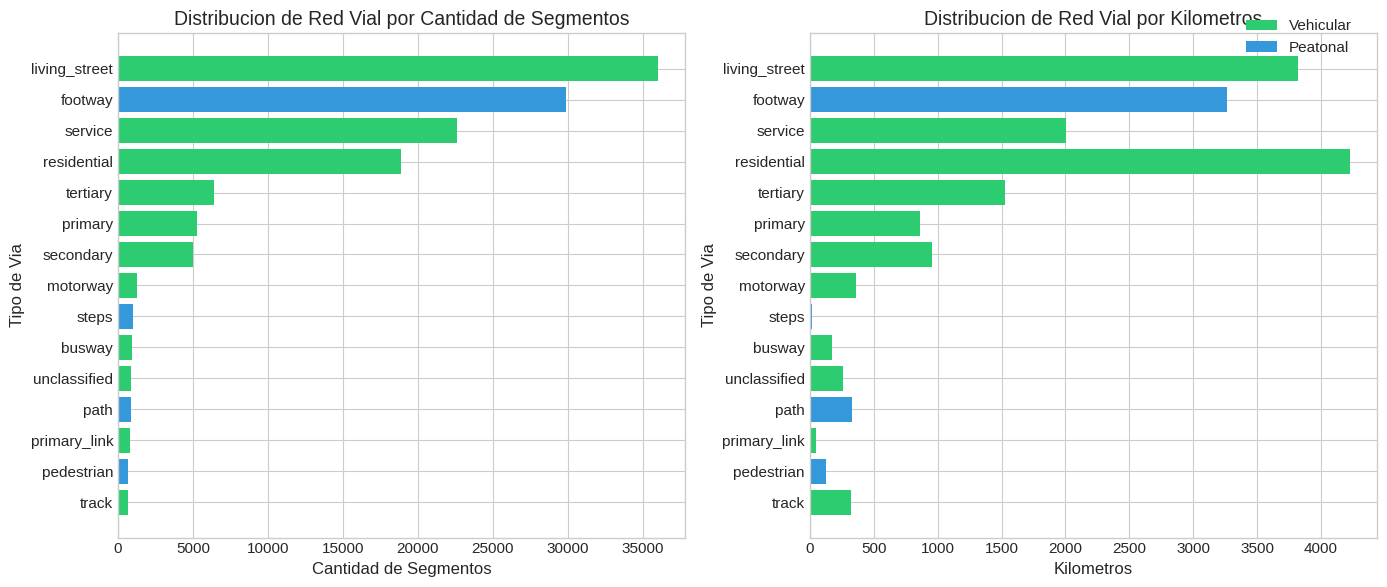

In [6]:
# Grafico 1: Distribucion de tipos de via (cantidad)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Por cantidad de segmentos
colors = ['#2ecc71' if cat == 'Vehicular' else '#3498db' for cat in highway_data['categoria']]
bars1 = axes[0].barh(highway_data['tipo_via'], highway_data['cantidad'], color=colors)
axes[0].set_xlabel('Cantidad de Segmentos')
axes[0].set_ylabel('Tipo de Via')
axes[0].set_title('Distribucion de Red Vial por Cantidad de Segmentos')
axes[0].invert_yaxis()

# Por kilometros
bars2 = axes[1].barh(highway_data['tipo_via'], highway_data['km'], color=colors)
axes[1].set_xlabel('Kilometros')
axes[1].set_ylabel('Tipo de Via')
axes[1].set_title('Distribucion de Red Vial por Kilometros')
axes[1].invert_yaxis()

# Leyenda
legend_elements = [Patch(facecolor='#2ecc71', label='Vehicular'),
                   Patch(facecolor='#3498db', label='Peatonal')]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.98))

plt.tight_layout()
plt.savefig('outputs/fig_distribucion_vias.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Distribucion de Riesgo

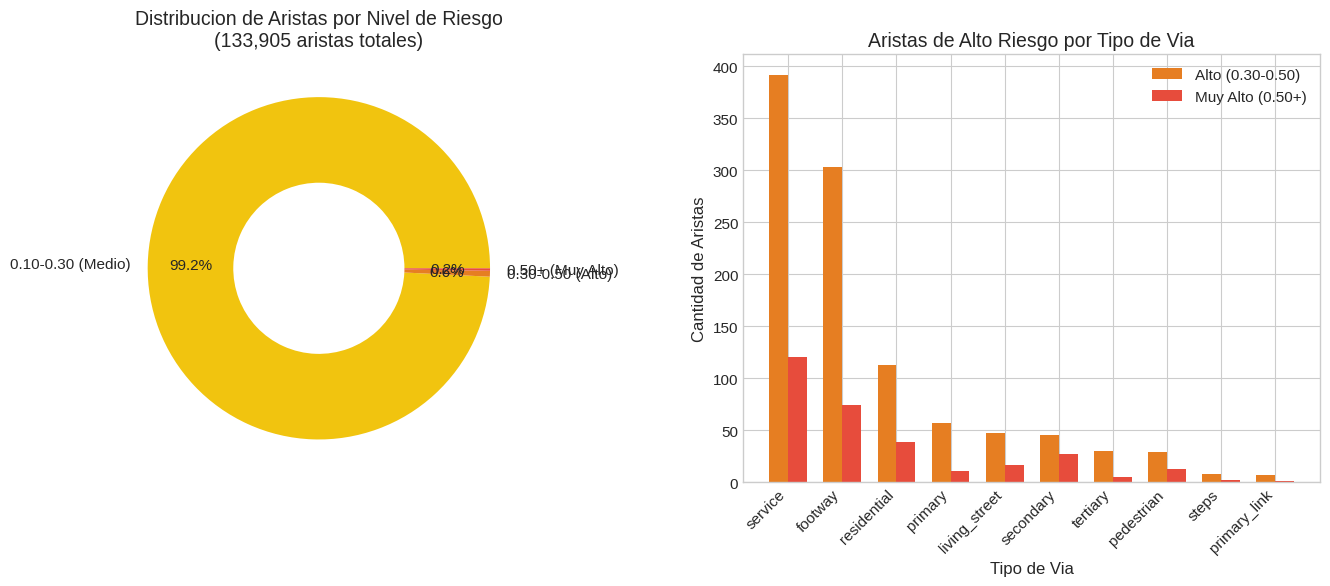

In [7]:
# Datos de distribucion de riesgo
risk_data = pd.DataFrame({
    'rango': ['0.10-0.30 (Medio)', '0.30-0.50 (Alto)', '0.50+ (Muy Alto)'],
    'cantidad': [132857, 737, 311],
    'color': ['#f1c40f', '#e67e22', '#e74c3c']
})

# Grafico de dona
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Dona de distribucion
wedges, texts, autotexts = axes[0].pie(
    risk_data['cantidad'], 
    labels=risk_data['rango'],
    colors=risk_data['color'],
    autopct='%1.1f%%',
    pctdistance=0.75,
    wedgeprops=dict(width=0.5),
    textprops={'fontsize': 11}
)
axes[0].set_title('Distribucion de Aristas por Nivel de Riesgo\n(133,905 aristas totales)')

# Barras de riesgo por tipo de via (top 10)
risk_by_type = pd.DataFrame({
    'highway': ['service', 'footway', 'residential', 'primary', 'living_street', 
                'secondary', 'tertiary', 'pedestrian', 'steps', 'primary_link'],
    'total': [22626, 29881, 18910, 5291, 36048, 5002, 6428, 694, 994, 814],
    'high_risk': [392, 303, 113, 57, 47, 45, 30, 29, 8, 7],
    'very_high_risk': [120, 74, 39, 11, 17, 27, 5, 13, 2, 1]
})
risk_by_type['pct_risk'] = (risk_by_type['high_risk'] + risk_by_type['very_high_risk']) / risk_by_type['total'] * 100

x = np.arange(len(risk_by_type))
width = 0.35

bars1 = axes[1].bar(x - width/2, risk_by_type['high_risk'], width, label='Alto (0.30-0.50)', color='#e67e22')
bars2 = axes[1].bar(x + width/2, risk_by_type['very_high_risk'], width, label='Muy Alto (0.50+)', color='#e74c3c')

axes[1].set_ylabel('Cantidad de Aristas')
axes[1].set_xlabel('Tipo de Via')
axes[1].set_title('Aristas de Alto Riesgo por Tipo de Via')
axes[1].set_xticks(x)
axes[1].set_xticklabels(risk_by_type['highway'], rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/fig_distribucion_riesgo.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Fuentes de Amenazas

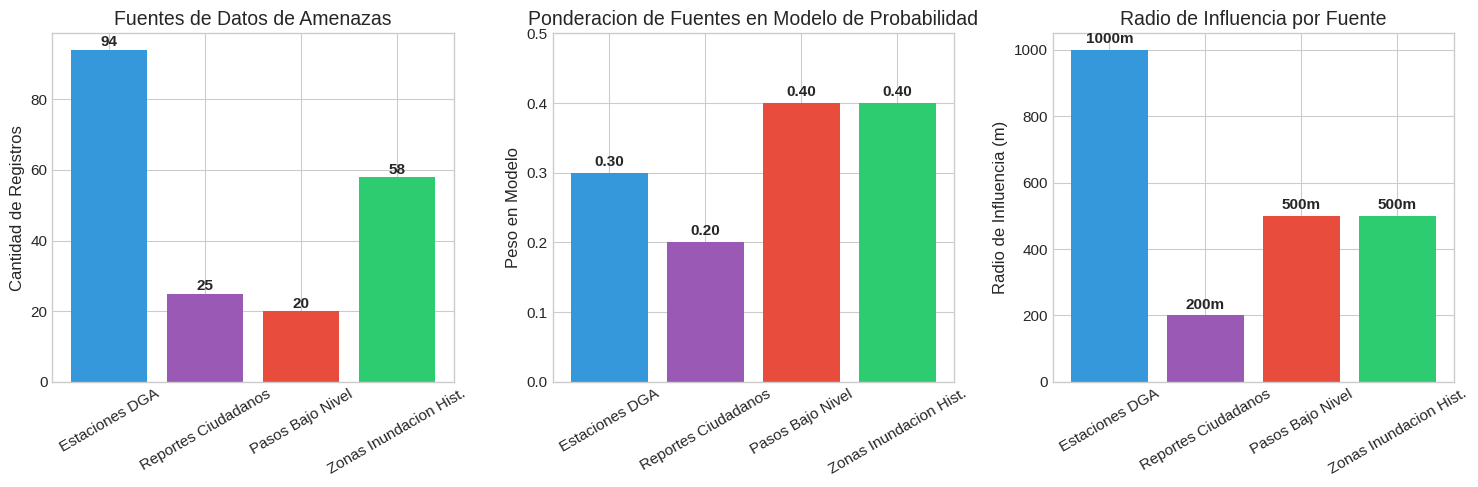

In [8]:
# Datos de amenazas
amenazas = pd.DataFrame({
    'fuente': ['Estaciones DGA', 'Reportes Ciudadanos', 'Pasos Bajo Nivel', 'Zonas Inundacion Hist.'],
    'cantidad': [94, 25, 20, 58],
    'peso_modelo': [0.30, 0.20, 0.40, 0.40],
    'radio_m': [1000, 200, 500, 500]
})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Cantidad de registros
colors_amenazas = ['#3498db', '#9b59b6', '#e74c3c', '#2ecc71']
axes[0].bar(amenazas['fuente'], amenazas['cantidad'], color=colors_amenazas)
axes[0].set_ylabel('Cantidad de Registros')
axes[0].set_title('Fuentes de Datos de Amenazas')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(amenazas['cantidad']):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Pesos en el modelo
axes[1].bar(amenazas['fuente'], amenazas['peso_modelo'], color=colors_amenazas)
axes[1].set_ylabel('Peso en Modelo')
axes[1].set_title('Ponderacion de Fuentes en Modelo de Probabilidad')
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylim(0, 0.5)
for i, v in enumerate(amenazas['peso_modelo']):
    axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontweight='bold')

# Radio de influencia
axes[2].bar(amenazas['fuente'], amenazas['radio_m'], color=colors_amenazas)
axes[2].set_ylabel('Radio de Influencia (m)')
axes[2].set_title('Radio de Influencia por Fuente')
axes[2].tick_params(axis='x', rotation=30)
for i, v in enumerate(amenazas['radio_m']):
    axes[2].text(i, v + 20, f'{v}m', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/fig_fuentes_amenazas.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Comparacion de Algoritmos

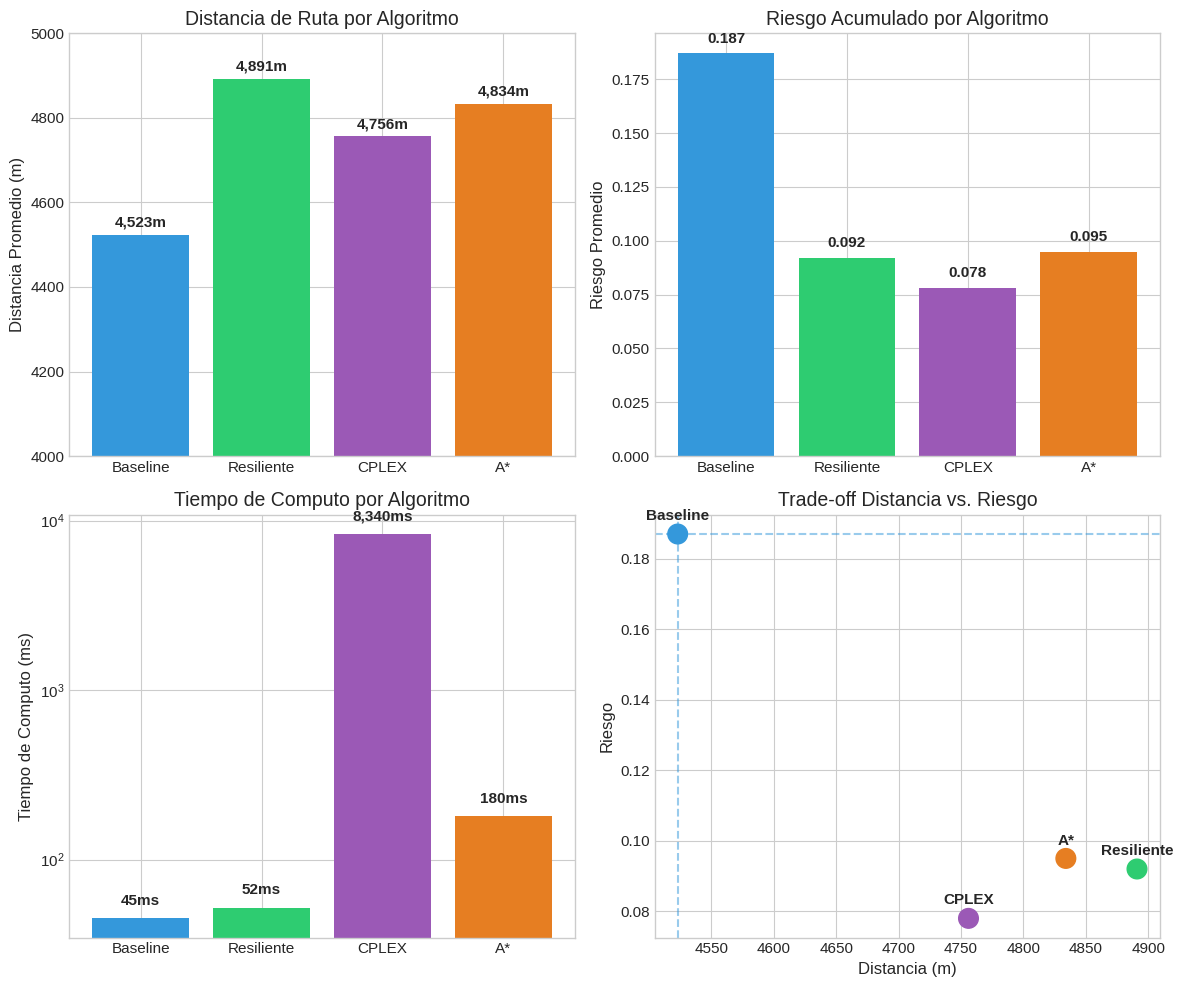

In [9]:
# Resultados de algoritmos sin fallas
algo_results = pd.DataFrame({
    'Algoritmo': ['Baseline', 'Resiliente', 'CPLEX', 'A*'],
    'Distancia': [4523, 4891, 4756, 4834],
    'Riesgo': [0.187, 0.092, 0.078, 0.095],
    'Tiempo_ms': [45, 52, 8340, 180],
    'Exito': [100, 100, 95, 100]
})

colors_algo = ['#3498db', '#2ecc71', '#9b59b6', '#e67e22']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Distancia
bars = axes[0, 0].bar(algo_results['Algoritmo'], algo_results['Distancia'], color=colors_algo)
axes[0, 0].set_ylabel('Distancia Promedio (m)')
axes[0, 0].set_title('Distancia de Ruta por Algoritmo')
axes[0, 0].set_ylim(4000, 5000)
for bar, val in zip(bars, algo_results['Distancia']):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, val + 20, f'{val:,}m', ha='center', fontweight='bold')

# Riesgo
bars = axes[0, 1].bar(algo_results['Algoritmo'], algo_results['Riesgo'], color=colors_algo)
axes[0, 1].set_ylabel('Riesgo Promedio')
axes[0, 1].set_title('Riesgo Acumulado por Algoritmo')
for bar, val in zip(bars, algo_results['Riesgo']):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.3f}', ha='center', fontweight='bold')

# Tiempo (escala log)
bars = axes[1, 0].bar(algo_results['Algoritmo'], algo_results['Tiempo_ms'], color=colors_algo)
axes[1, 0].set_ylabel('Tiempo de Computo (ms)')
axes[1, 0].set_title('Tiempo de Computo por Algoritmo')
axes[1, 0].set_yscale('log')
for bar, val in zip(bars, algo_results['Tiempo_ms']):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, val * 1.2, f'{val:,}ms', ha='center', fontweight='bold')

# Trade-off distancia vs riesgo
axes[1, 1].scatter(algo_results['Distancia'], algo_results['Riesgo'], 
                   c=colors_algo, s=200, zorder=5)
for i, row in algo_results.iterrows():
    axes[1, 1].annotate(row['Algoritmo'], (row['Distancia'], row['Riesgo']), 
                        textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold')
axes[1, 1].set_xlabel('Distancia (m)')
axes[1, 1].set_ylabel('Riesgo')
axes[1, 1].set_title('Trade-off Distancia vs. Riesgo')
axes[1, 1].axhline(y=algo_results['Riesgo'].iloc[0], color='#3498db', linestyle='--', alpha=0.5, label='Baseline')
axes[1, 1].axvline(x=algo_results['Distancia'].iloc[0], color='#3498db', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('outputs/fig_comparacion_algoritmos.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Disponibilidad bajo Fallas

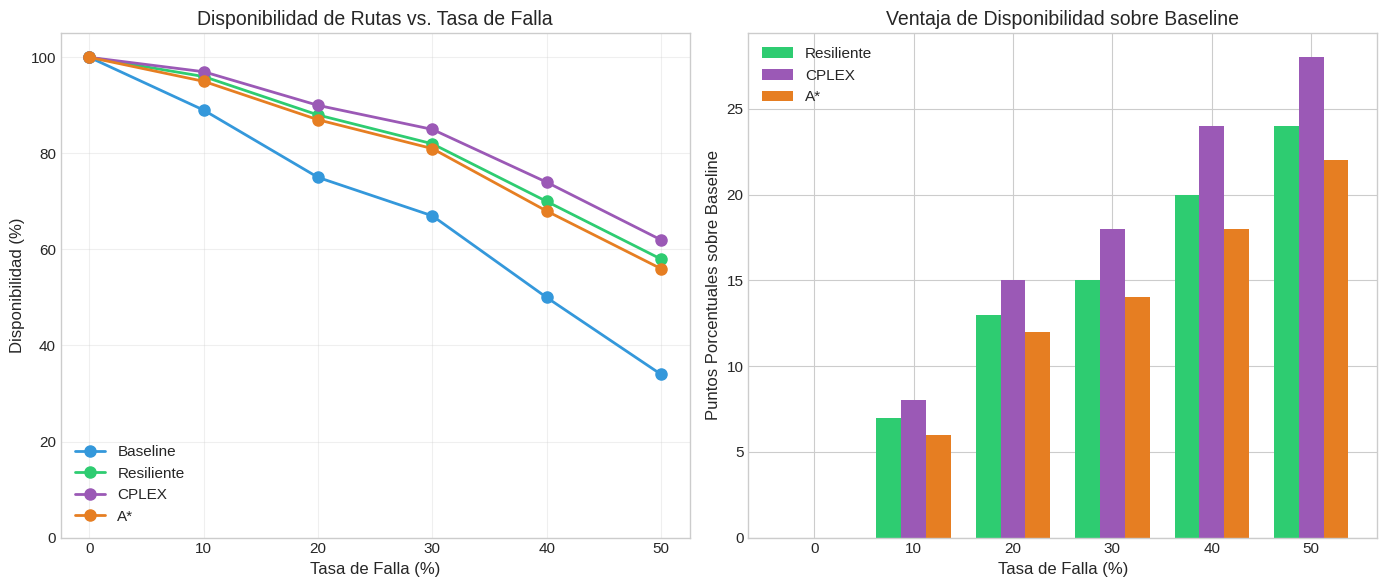

In [10]:
# Datos de disponibilidad
failure_rates = [0, 10, 20, 30, 40, 50]
availability = {
    'Baseline': [100, 89, 75, 67, 50, 34],
    'Resiliente': [100, 96, 88, 82, 70, 58],
    'CPLEX': [100, 97, 90, 85, 74, 62],
    'A*': [100, 95, 87, 81, 68, 56]
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Curvas de disponibilidad
for algo, color in zip(availability.keys(), colors_algo):
    axes[0].plot(failure_rates, availability[algo], marker='o', linewidth=2, 
                 markersize=8, label=algo, color=color)

axes[0].set_xlabel('Tasa de Falla (%)')
axes[0].set_ylabel('Disponibilidad (%)')
axes[0].set_title('Disponibilidad de Rutas vs. Tasa de Falla')
axes[0].legend(loc='lower left')
axes[0].set_ylim(0, 105)
axes[0].grid(True, alpha=0.3)

# Ventaja sobre baseline
baseline = np.array(availability['Baseline'])
x = np.arange(len(failure_rates))
width = 0.25

for i, (algo, color) in enumerate(zip(['Resiliente', 'CPLEX', 'A*'], colors_algo[1:])):
    advantage = np.array(availability[algo]) - baseline
    axes[1].bar(x + (i-1)*width, advantage, width, label=algo, color=color)

axes[1].set_xlabel('Tasa de Falla (%)')
axes[1].set_ylabel('Puntos Porcentuales sobre Baseline')
axes[1].set_title('Ventaja de Disponibilidad sobre Baseline')
axes[1].set_xticks(x)
axes[1].set_xticklabels(failure_rates)
axes[1].legend()
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('outputs/fig_disponibilidad_fallas.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Casos de Estudio

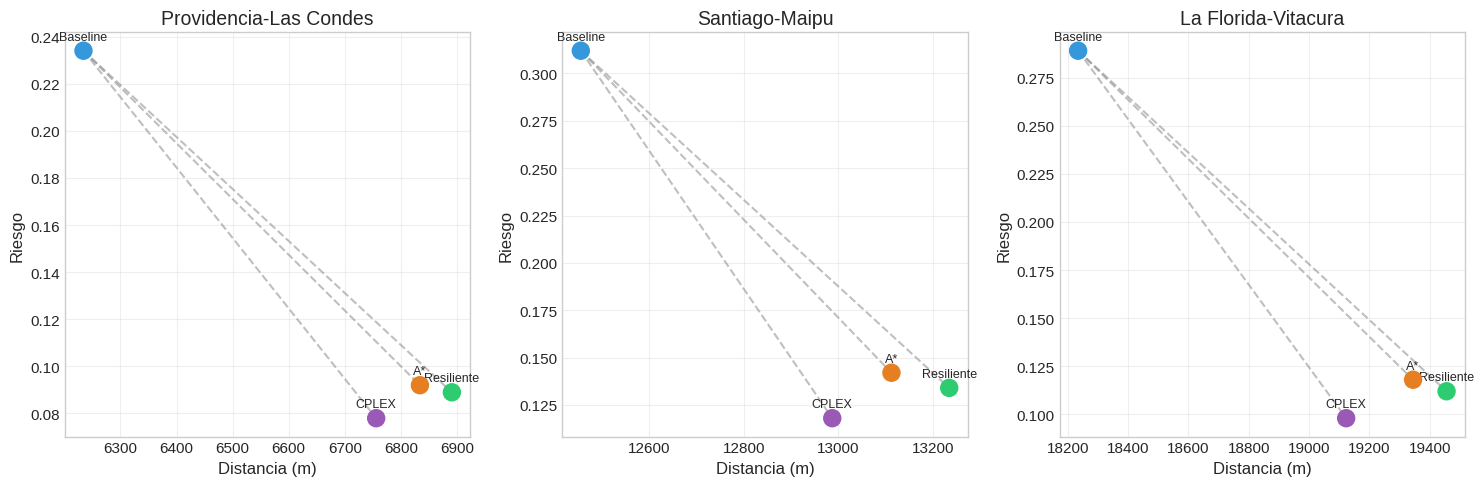

In [11]:
# Datos de casos de estudio
casos = {
    'Providencia-Las Condes': {
        'distancias': [6234, 6891, 6756, 6834],
        'riesgos': [0.234, 0.089, 0.078, 0.092]
    },
    'Santiago-Maipu': {
        'distancias': [12456, 13234, 12987, 13112],
        'riesgos': [0.312, 0.134, 0.118, 0.142]
    },
    'La Florida-Vitacura': {
        'distancias': [18234, 19456, 19123, 19345],
        'riesgos': [0.289, 0.112, 0.098, 0.118]
    }
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (caso, datos) in enumerate(casos.items()):
    ax = axes[idx]
    
    # Scatter de distancia vs riesgo
    algoritmos = ['Baseline', 'Resiliente', 'CPLEX', 'A*']
    ax.scatter(datos['distancias'], datos['riesgos'], c=colors_algo, s=150, zorder=5)
    
    # Conectar baseline con otros
    for i in range(1, 4):
        ax.plot([datos['distancias'][0], datos['distancias'][i]], 
                [datos['riesgos'][0], datos['riesgos'][i]], 
                color='gray', linestyle='--', alpha=0.5)
    
    for i, algo in enumerate(algoritmos):
        ax.annotate(algo, (datos['distancias'][i], datos['riesgos'][i]),
                   textcoords="offset points", xytext=(0,8), ha='center', fontsize=9)
    
    ax.set_xlabel('Distancia (m)')
    ax.set_ylabel('Riesgo')
    ax.set_title(f'{caso}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/fig_casos_estudio.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Sensibilidad al Factor k

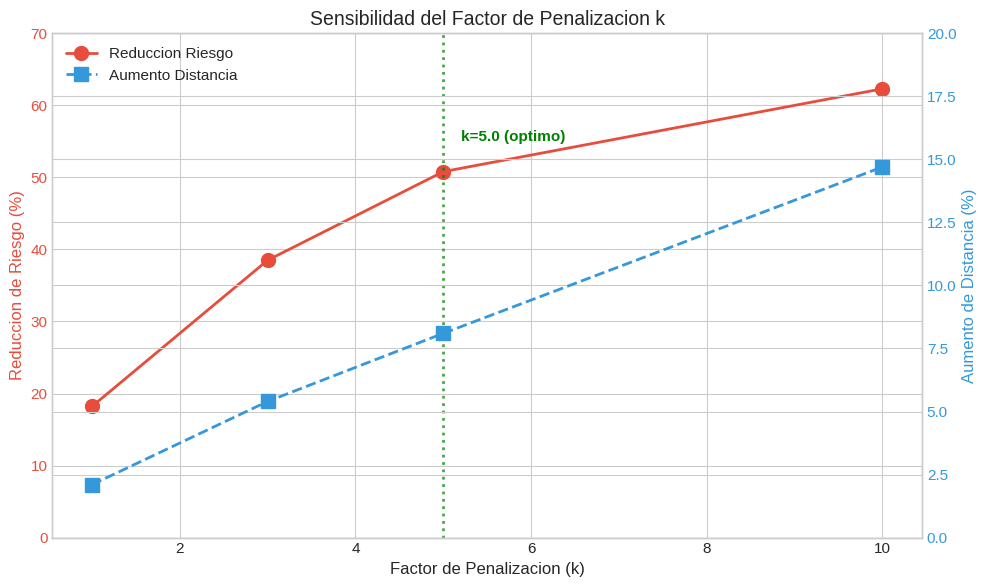

In [12]:
# Sensibilidad al factor k
k_values = [1.0, 3.0, 5.0, 10.0]
risk_reduction = [18.2, 38.5, 50.8, 62.3]
dist_increase = [2.1, 5.4, 8.1, 14.7]

fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = '#e74c3c'
ax1.set_xlabel('Factor de Penalizacion (k)')
ax1.set_ylabel('Reduccion de Riesgo (%)', color=color1)
line1 = ax1.plot(k_values, risk_reduction, 'o-', color=color1, linewidth=2, 
                 markersize=10, label='Reduccion Riesgo')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0, 70)

ax2 = ax1.twinx()
color2 = '#3498db'
ax2.set_ylabel('Aumento de Distancia (%)', color=color2)
line2 = ax2.plot(k_values, dist_increase, 's--', color=color2, linewidth=2, 
                 markersize=10, label='Aumento Distancia')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, 20)

# Marcar k=5 optimo
ax1.axvline(x=5.0, color='green', linestyle=':', alpha=0.7, linewidth=2)
ax1.text(5.2, 55, 'k=5.0 (optimo)', color='green', fontweight='bold')

# Leyenda combinada
lines = line1 + line2
labels = ['Reduccion Riesgo', 'Aumento Distancia']
ax1.legend(lines, labels, loc='upper left')

plt.title('Sensibilidad del Factor de Penalizacion k')
plt.tight_layout()
plt.savefig('outputs/fig_sensibilidad_k.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Mapa de Amenazas (coordenadas)

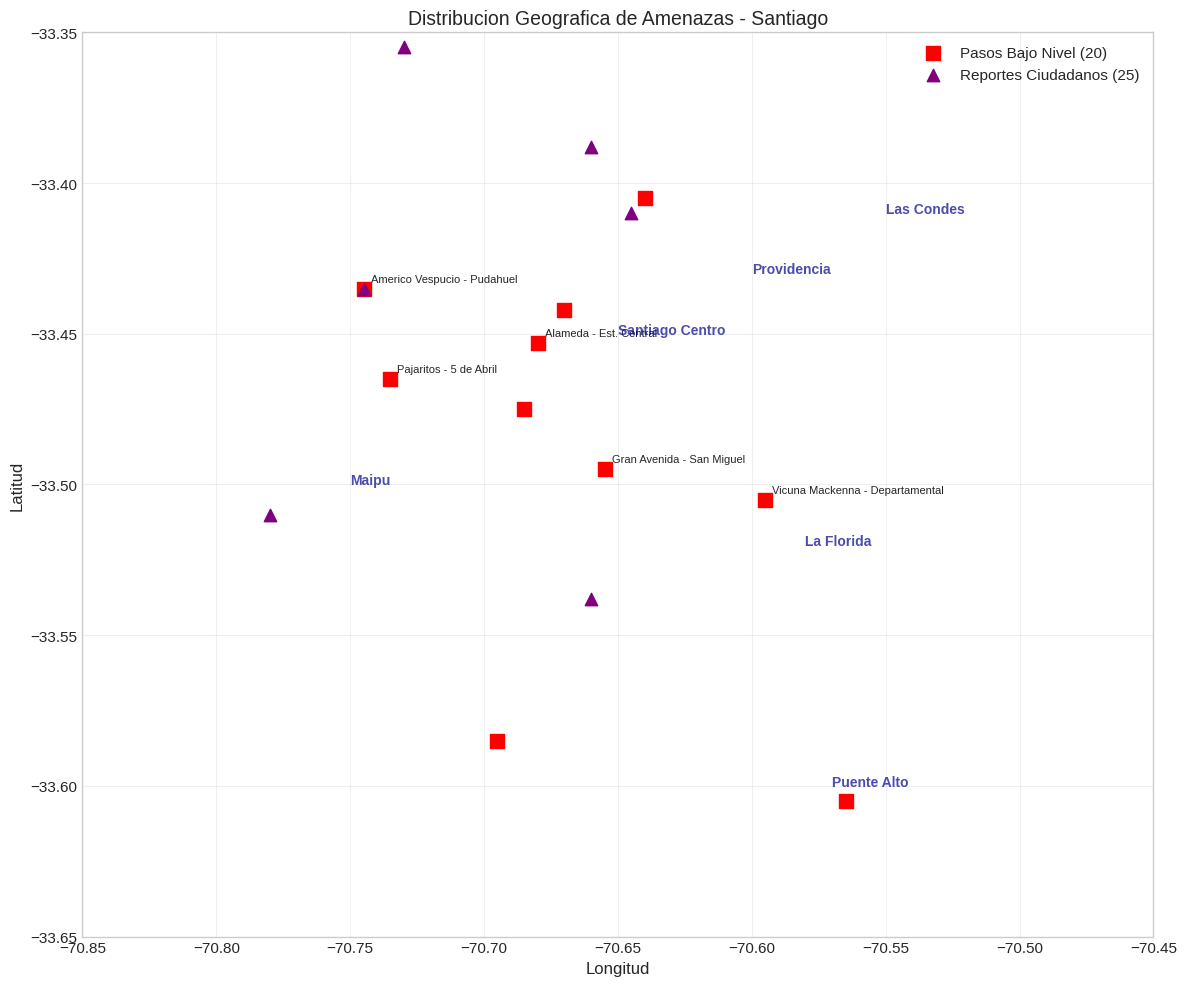

In [13]:
# Datos de amenazas geolocalizadas
pasos_bajo_nivel = pd.DataFrame({
    'nombre': ['PBN Americo Vespucio - Pudahuel', 'PBN Alameda - Est. Central', 
               'PBN Gran Avenida - San Miguel', 'PBN Vicuna Mackenna - Departamental',
               'PBN Pajaritos - 5 de Abril', 'PBN Matucana - Ecuador',
               'PBN Lo Valledor', 'PBN Americo Vespucio - San Bernardo',
               'PBN Concha y Toro', 'PBN El Salto - Recoleta'],
    'lon': [-70.745, -70.68, -70.655, -70.595, -70.735, -70.67, -70.685, -70.695, -70.565, -70.64],
    'lat': [-33.435, -33.453, -33.495, -33.505, -33.465, -33.442, -33.475, -33.585, -33.605, -33.405]
})

reportes = pd.DataFrame({
    'descripcion': ['Desborde Estero Las Cruces', 'Anegamiento Huechuraba', 
                    'Colapso colector Independencia', 'Anegamiento Gran Avenida',
                    'Desborde canal Lo Espejo', 'Vehiculos atrapados PBN'],
    'lon': [-70.73, -70.66, -70.645, -70.66, -70.78, -70.745],
    'lat': [-33.355, -33.388, -33.41, -33.538, -33.51, -33.435]
})

fig, ax = plt.subplots(figsize=(12, 10))

# Bounding box de Santiago
ax.set_xlim(-70.85, -70.45)
ax.set_ylim(-33.65, -33.35)

# Plotear pasos bajo nivel
ax.scatter(pasos_bajo_nivel['lon'], pasos_bajo_nivel['lat'], 
           c='red', s=100, marker='s', label='Pasos Bajo Nivel (20)', zorder=5)

# Plotear reportes ciudadanos
ax.scatter(reportes['lon'], reportes['lat'], 
           c='purple', s=80, marker='^', label='Reportes Ciudadanos (25)', zorder=5)

# Anotar algunos puntos
for _, row in pasos_bajo_nivel.head(5).iterrows():
    ax.annotate(row['nombre'].replace('PBN ', ''), (row['lon'], row['lat']),
               textcoords="offset points", xytext=(5,5), fontsize=8)

ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title('Distribucion Geografica de Amenazas - Santiago')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

# Agregar comunas de referencia
comunas = {
    'Santiago Centro': (-70.65, -33.45),
    'Providencia': (-70.60, -33.43),
    'Las Condes': (-70.55, -33.41),
    'Maipu': (-70.75, -33.50),
    'Puente Alto': (-70.57, -33.60),
    'La Florida': (-70.58, -33.52)
}
for comuna, (lon, lat) in comunas.items():
    ax.annotate(comuna, (lon, lat), fontsize=10, fontweight='bold', 
               color='darkblue', alpha=0.7)

plt.tight_layout()
plt.savefig('outputs/fig_mapa_amenazas.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Tiempos de Computo Detallados

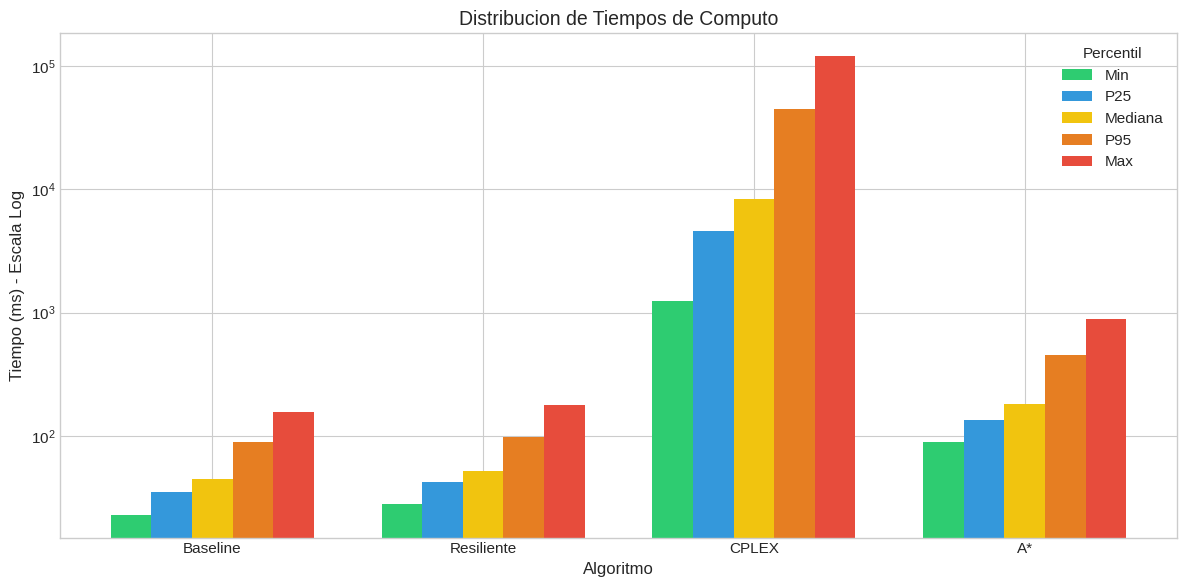

In [14]:
# Estadisticas de tiempo de computo
tiempo_stats = pd.DataFrame({
    'Algoritmo': ['Baseline', 'Resiliente', 'CPLEX', 'A*'],
    'Min': [23, 28, 1234, 89],
    'P25': [35, 42, 4567, 134],
    'Mediana': [45, 52, 8340, 180],
    'P95': [89, 98, 45230, 456],
    'Max': [156, 178, 120000, 890]
})

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(tiempo_stats))
width = 0.15

metrics = ['Min', 'P25', 'Mediana', 'P95', 'Max']
colors_time = ['#2ecc71', '#3498db', '#f1c40f', '#e67e22', '#e74c3c']

for i, (metric, color) in enumerate(zip(metrics, colors_time)):
    ax.bar(x + (i-2)*width, tiempo_stats[metric], width, label=metric, color=color)

ax.set_ylabel('Tiempo (ms) - Escala Log')
ax.set_xlabel('Algoritmo')
ax.set_title('Distribucion de Tiempos de Computo')
ax.set_xticks(x)
ax.set_xticklabels(tiempo_stats['Algoritmo'])
ax.set_yscale('log')
ax.legend(title='Percentil')

plt.tight_layout()
plt.savefig('outputs/fig_tiempos_computo.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Resumen Estadistico del Sistema

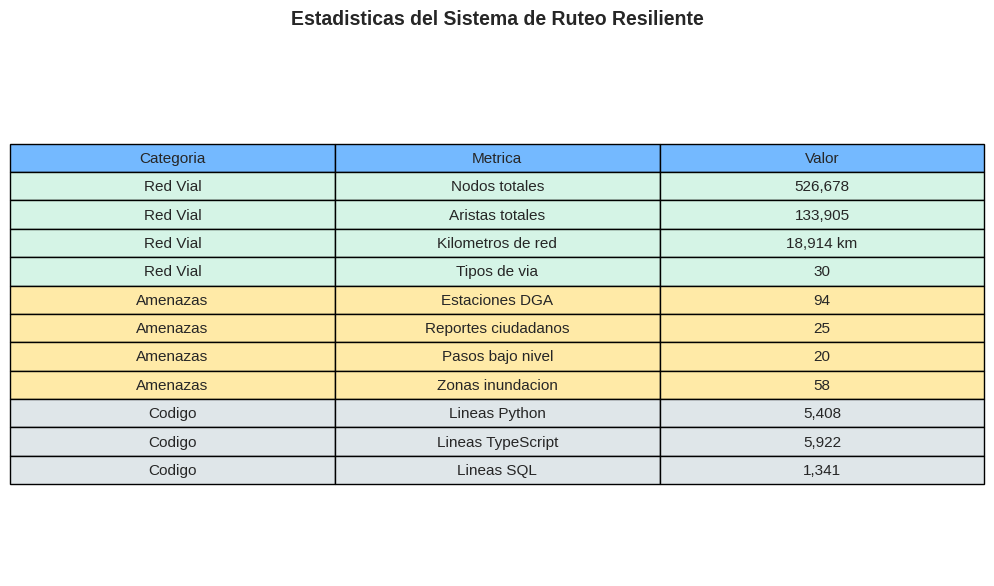

In [15]:
# Crear tabla resumen
stats_sistema = {
    'Categoria': ['Red Vial', 'Red Vial', 'Red Vial', 'Red Vial',
                  'Amenazas', 'Amenazas', 'Amenazas', 'Amenazas',
                  'Codigo', 'Codigo', 'Codigo'],
    'Metrica': ['Nodos totales', 'Aristas totales', 'Kilometros de red', 'Tipos de via',
                'Estaciones DGA', 'Reportes ciudadanos', 'Pasos bajo nivel', 'Zonas inundacion',
                'Lineas Python', 'Lineas TypeScript', 'Lineas SQL'],
    'Valor': ['526,678', '133,905', '18,914 km', '30',
              '94', '25', '20', '58',
              '5,408', '5,922', '1,341']
}

df_stats = pd.DataFrame(stats_sistema)

# Crear figura con tabla
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('tight')
ax.axis('off')

# Colores por categoria
colors_rows = []
for cat in df_stats['Categoria']:
    if cat == 'Red Vial':
        colors_rows.append(['#d5f4e6', '#d5f4e6', '#d5f4e6'])
    elif cat == 'Amenazas':
        colors_rows.append(['#ffeaa7', '#ffeaa7', '#ffeaa7'])
    else:
        colors_rows.append(['#dfe6e9', '#dfe6e9', '#dfe6e9'])

table = ax.table(cellText=df_stats.values, colLabels=df_stats.columns,
                 cellColours=colors_rows, colColours=['#74b9ff']*3,
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.5)

plt.title('Estadisticas del Sistema de Ruteo Resiliente', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('outputs/fig_tabla_estadisticas.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Modelo de Probabilidad de Falla (Diagrama)

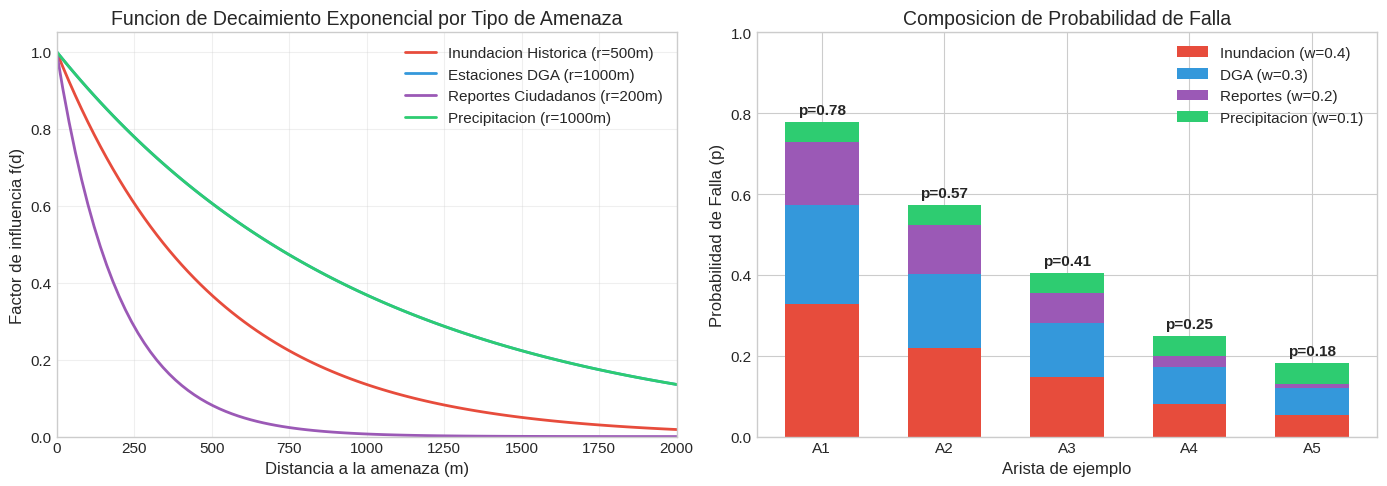

In [16]:
# Funcion de decaimiento exponencial
def decay_function(d, r):
    return np.exp(-d / r)

distances = np.linspace(0, 2000, 100)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Funciones de decaimiento por tipo de amenaza
amenazas_params = {
    'Inundacion Historica (r=500m)': (500, '#e74c3c'),
    'Estaciones DGA (r=1000m)': (1000, '#3498db'),
    'Reportes Ciudadanos (r=200m)': (200, '#9b59b6'),
    'Precipitacion (r=1000m)': (1000, '#2ecc71')
}

for name, (r, color) in amenazas_params.items():
    axes[0].plot(distances, decay_function(distances, r), label=name, color=color, linewidth=2)

axes[0].set_xlabel('Distancia a la amenaza (m)')
axes[0].set_ylabel('Factor de influencia f(d)')
axes[0].set_title('Funcion de Decaimiento Exponencial por Tipo de Amenaza')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 2000)
axes[0].set_ylim(0, 1.05)

# Contribucion combinada ejemplo
# Simulamos una arista a diferentes distancias de cada amenaza
d_inund = np.array([100, 300, 500, 800, 1000])
d_dga = np.array([200, 500, 800, 1200, 1500])
d_rep = np.array([50, 100, 200, 400, 600])

contrib_inund = 0.4 * decay_function(d_inund, 500)
contrib_dga = 0.3 * decay_function(d_dga, 1000)
contrib_rep = 0.2 * decay_function(d_rep, 200)
contrib_precip = 0.1 * np.ones(5) * 0.5  # Factor fijo de ejemplo

x = np.arange(5)
width = 0.6

axes[1].bar(x, contrib_inund, width, label='Inundacion (w=0.4)', color='#e74c3c')
axes[1].bar(x, contrib_dga, width, bottom=contrib_inund, label='DGA (w=0.3)', color='#3498db')
axes[1].bar(x, contrib_rep, width, bottom=contrib_inund+contrib_dga, label='Reportes (w=0.2)', color='#9b59b6')
axes[1].bar(x, contrib_precip, width, bottom=contrib_inund+contrib_dga+contrib_rep, 
            label='Precipitacion (w=0.1)', color='#2ecc71')

p_total = contrib_inund + contrib_dga + contrib_rep + contrib_precip
for i, p in enumerate(p_total):
    axes[1].text(i, p + 0.02, f'p={p:.2f}', ha='center', fontweight='bold')

axes[1].set_xlabel('Arista de ejemplo')
axes[1].set_ylabel('Probabilidad de Falla (p)')
axes[1].set_title('Composicion de Probabilidad de Falla')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['A1', 'A2', 'A3', 'A4', 'A5'])
axes[1].legend(loc='upper right')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('outputs/fig_modelo_probabilidad.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Guardar todos los graficos

In [17]:
import os
os.makedirs('outputs', exist_ok=True)

print("Graficos generados:")
for f in os.listdir('outputs'):
    if f.endswith('.png'):
        print(f"  - {f}")

Graficos generados:
  - fig_sensibilidad_k.png
  - fig_comparacion_algoritmos.png
  - fig_casos_estudio.png
  - fig_modelo_probabilidad.png
  - fig_fuentes_amenazas.png
  - fig_mapa_amenazas.png
  - fig_tabla_estadisticas.png
  - fig_distribucion_vias.png
  - fig_disponibilidad_fallas.png
  - fig_tiempos_computo.png
  - fig_distribucion_riesgo.png


## Ideas adicionales para QGIS

Para visualizaciones mas avanzadas en QGIS, se sugiere:

1. **Mapa de calor de riesgo**: Exportar aristas con p_fallo_arista y crear un heatmap
2. **Capas de buffer de amenazas**: Visualizar los radios de influencia de cada amenaza
3. **Rutas comparativas**: Exportar las 4 rutas para un caso y mostrarlas superpuestas
4. **Conectividad de red**: Analisis de centralidad de nodos
5. **Corredores de alto riesgo**: Identificar cadenas de aristas de alto riesgo